In [1]:
import spacy
nlp = spacy.load('en_core_web_sm')
print("spaCy ready!")

spaCy ready!


In [3]:
import pandas as pd

df = pd.read_csv("Resume.csv")
print(df.shape)
df.head()

(2484, 4)


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [4]:
print(df['Category'].value_counts())
print("Total resumes:", len(df))

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64
Total resumes: 2484


In [5]:
# Let's work with Data Science resumes
target_category = 'DATA SCIENCE'
resumes = df[df['Category'] == target_category][['ID', 'Resume_str']].copy()
resumes.columns = ['ID', 'resume_text']
resumes = resumes.reset_index(drop=True)
print(resumes.shape)

(0, 2)


In [6]:
target_category = 'INFORMATION-TECHNOLOGY'
resumes = df[df['Category'] == target_category][['ID', 'Resume_str']].copy()
resumes.columns = ['ID', 'resume_text']
resumes = resumes.reset_index(drop=True)
print(resumes.shape)
resumes.head(2)

(120, 2)


,ID,resume_text
0,36856210,INFORMATION TECHNOLOGY Summar...
1,21780877,INFORMATION TECHNOLOGY SPECIALIST\tGS...


In [7]:
job_description = """
We are looking for a Software Engineer with experience in Python, Java, SQL, 
machine learning, data analysis, cloud computing, AWS, REST APIs, 
problem solving, communication, teamwork, and agile development.
"""

import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

resumes['clean_resume'] = resumes['resume_text'].apply(clean_text)
job_desc_clean = clean_text(job_description)
print("Done cleaning!")

Done cleaning!


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Combine job description + all resumes for vectorization
all_texts = [job_desc_clean] + list(resumes['clean_resume'])

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(all_texts)

# Calculate similarity of each resume to job description
job_vector = tfidf_matrix[0]
resume_vectors = tfidf_matrix[1:]

scores = cosine_similarity(job_vector, resume_vectors)[0]
resumes['match_score'] = scores
print("Scoring done!")

Scoring done!


In [9]:
ranked = resumes[['ID', 'match_score']].sort_values('match_score', ascending=False).reset_index(drop=True)
ranked['rank'] = ranked.index + 1
print(ranked.head(10))

         ID  match_score  rank
0  83816738     0.155267     1
1  20824105     0.133905     2
2  28035460     0.105884     3
3  25990239     0.082624     4
4  13385306     0.081820     5
5  22450718     0.080685     6
6  36434348     0.080477     7
7  33381211     0.079392     8
8  39413067     0.077857     9
9  18067556     0.077387    10


In [10]:
required_skills = ['python', 'java', 'sql', 'machine learning', 'aws', 
                   'cloud', 'rest', 'agile', 'communication', 'teamwork']

def get_missing_skills(resume_text):
    missing = [skill for skill in required_skills if skill not in resume_text.lower()]
    return missing

resumes['missing_skills'] = resumes['clean_resume'].apply(get_missing_skills)
print(resumes[['ID', 'match_score', 'missing_skills']].sort_values('match_score', ascending=False).head(5))

          ID  match_score                                     missing_skills
80  83816738     0.155267               [python, machine learning, teamwork]
81  20824105     0.133905  [java, sql, machine learning, rest, agile, tea...
52  28035460     0.105884  [python, java, sql, machine learning, aws, res...
3   25990239     0.082624  [python, java, sql, machine learning, aws, clo...
26  13385306     0.081820  [python, java, machine learning, aws, cloud, r...


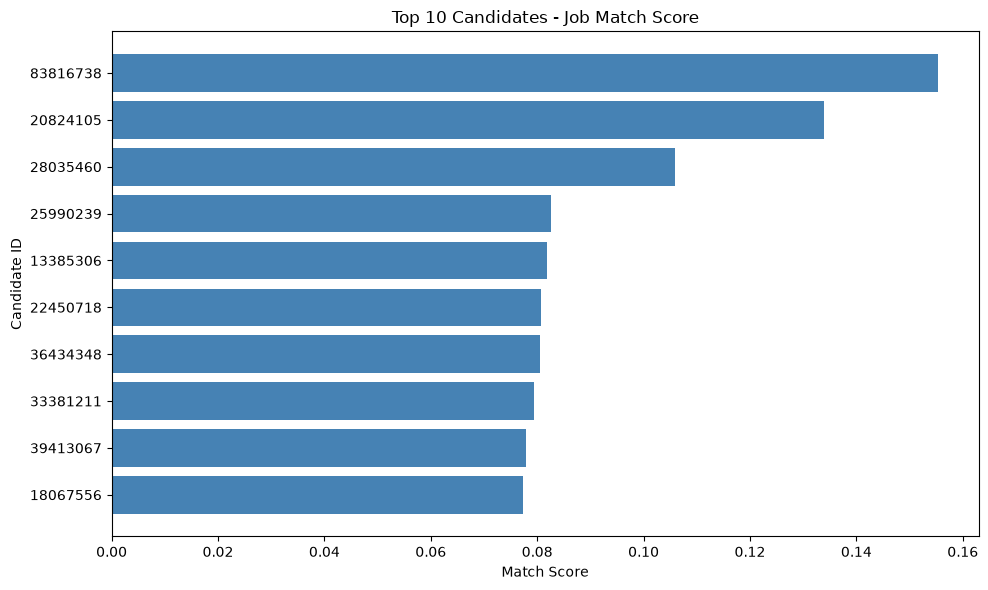

In [11]:
import matplotlib.pyplot as plt

top10 = ranked.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10['ID'].astype(str), top10['match_score'], color='steelblue')
plt.xlabel('Match Score')
plt.ylabel('Candidate ID')
plt.title('Top 10 Candidates - Job Match Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [12]:
final_results = resumes[['ID', 'match_score', 'missing_skills']].sort_values('match_score', ascending=False).reset_index(drop=True)
final_results['rank'] = final_results.index + 1
final_results['match_%'] = (final_results['match_score'] * 100).round(2)
print(final_results[['rank', 'ID', 'match_%', 'missing_skills']].head(10))

   rank        ID  match_%                                     missing_skills
0     1  83816738    15.53               [python, machine learning, teamwork]
1     2  20824105    13.39  [java, sql, machine learning, rest, agile, tea...
2     3  28035460    10.59  [python, java, sql, machine learning, aws, res...
3     4  25990239     8.26  [python, java, sql, machine learning, aws, clo...
4     5  13385306     8.18  [python, java, machine learning, aws, cloud, r...
5     6  22450718     8.07  [python, java, sql, machine learning, aws, clo...
6     7  36434348     8.05  [python, java, machine learning, aws, cloud, r...
7     8  33381211     7.94         [python, java, machine learning, teamwork]
8     9  39413067     7.79  [python, machine learning, aws, cloud, rest, a...
9    10  18067556     7.74  [java, machine learning, agile, communication,...


## Task 3: Resume / Candidate Screening System

### What Was Built
An ML-based resume screening system that automatically scores and ranks
120 IT candidates against a Software Engineer job description.

### How It Works
- Resume text is cleaned (lowercased, stopwords removed)
- TF-IDF vectorization converts text to numerical features
- Cosine similarity scores each resume against the job description
- Candidates are ranked by match score (highest = best fit)
- Missing skills are identified for each candidate

### Top Candidates
| Rank | Candidate ID | Match % | Key Missing Skills |
|------|-------------|---------|-------------------|
| 1 | 83816738 | 15.53% | Python, ML, Teamwork |
| 2 | 20824105 | 13.39% | Java, SQL, ML, Agile |
| 3 | 28035460 | 10.59% | Python, Java, SQL, ML |

### Business Value
This system helps recruiters:
- Shortlist top candidates in seconds instead of hours
- Identify skill gaps before interviews
- Make consistent, data-driven hiring decisions
- Reduce recruiter workload significantly

### Key Insight
Match scores are relatively low (max 15%) because resumes contain
broad IT experience while the job description targets specific skills.
In production, this system would improve with more specific job descriptions
and structured resume formats.